In [ ]:
from upxo.repqual.grain_network_repr_assesser import KREPR
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
input_dashboard = 'C:\\Development\\UPXO\\upxo_library\\src\\upxo\\demos\\gschar\\gschar3.xls'

In [1049]:
Msample, Mtarget = 29, 29
MsampleIncr, MtargetIncr = 1, 1
kr = KREPR.from_gsgen(gstype_tgt='mcgs2d', gstype_smp='mcgs2d',
                      is_smp_same_as_tgt = True,
                      characterize_tgt=True, characterize_smp=True,
					  tgt_dashboard=input_dashboard,
					  smp_dashboard=input_dashboard,
					  ordern=[1, 2],
                      tsid_source='user', ssid_source='user',
					  tid=np.arange(1, Mtarget, MtargetIncr), sid=np.arange(1, Msample, MsampleIncr),
                      _cim_='from_gsgen')
kr.set_rkf(js=True, wd=True, ksp=True, ed=True, nlsd=True,
           degcen=False, btwcen=False, clscen=False, egnvcen=False)
kr.calculate_rkf()

GENERATING TARGET GRAIN STRUCTURES
C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\demos\gschar\gschar3.xls
Algo_hops details
(('200.0', 100),)
[False]

 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 200.0, 1.0
     ymin, ymax, yinc: 0.0, 200.0, 1.0
     zmin, zmax, zinc: 0.0, 100.0, 1.0
     No. of states: 4
     Dimensionality: 2
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
GS temporal slice 7 stored
GS temporal slice 8 stored
GS temporal slice 9 stored
GS temporal slice 10 stored
GS temporal slice 11 stored
GS temporal slice 12 stored
GS temporal slice 13 stored
GS temporal slice 14 stored
GS temporal slice 15 stored
GS temporal slice 16 sto

In [1050]:
neighOrder = [1.0, 3.5]
kr.set_ordern(neighOrder)
kr.find_neigh_order_n(saa=True, throw=False)
kr.create_tgt_smp_networks(saa=True, throw=False)
kr.set_rkf(js=True, wd=True, ksp=True, ed=True, nlsd=True, degcen=False,
           btwcen=False, clscen=False, egnvcen=False)
kr.calculate_rkf()


Starting to extract neighbourhood data for target gs dataset
     O(n): 1.0, gsID: 10/28
     O(n): 1.0, gsID: 20/28
     O(n): 3.5, gsID: 10/28
     O(n): 3.5, gsID: 20/28
Starting to extract neighbourhood data for sample gs dataset
     O(n): 1.0, gsID: 10/28
     O(n): 1.0, gsID: 20/28
     O(n): 3.5, gsID: 10/28
     O(n): 3.5, gsID: 20/28
----------------------------------------
Creating networks for target grain structure dataset.
     O(n) = 1.0, gsID: 10/28
     O(n) = 1.0, gsID: 20/28
     O(n) = 3.5, gsID: 10/28
     O(n) = 3.5, gsID: 20/28
----------------------------------------
Creating networks for sample grain structure dataset.
     O(n) = 1.0, gsID: 10/28
     O(n) = 1.0, gsID: 20/28
     O(n) = 3.5, gsID: 10/28
     O(n) = 3.5, gsID: 20/28
----------------------------------------
Creating R-field data structures.
++++++++++++++++++++++++++++++++++++++
[1.0, 3.5] -------------
++++++++++++++++++++++++++++++++++++++
----------------------------------------
Calculating R

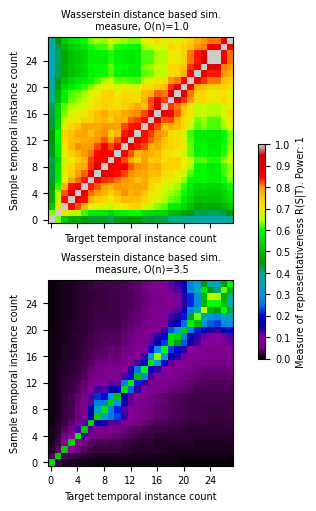

In [1051]:
kr.plot_rkf(neigh_orders=neighOrder, power=1, figsize=(7, 5), dpi=100,
            xtick_incr=4, ytick_incr=4, lfs=7, tfs=7,
            cmap='nipy_spectral', cbarticks=np.arange(0, 1.1, 0.1), cbfs=7,
            cbtitle='Measure of representativeness R(S|T)',
            cbfraction=0.046, cbpad=0.04, cbaspect=30, shrink=0.5,
            cborientation='vertical',
            flags={'rkf_js': False, 'rkf_wd': True,
                   'rkf_ksp': False, 'rkf_ed': False,
                   'rkf_nlsd': False, 'rkf_degcen': False,
                   'rkf_btwcen': False, 'rkf_clscen': False,
                   'rkf_egnvcen': False}, xlabel='Target temporal instance count',
                 ylabel='Sample temporal instance count',)

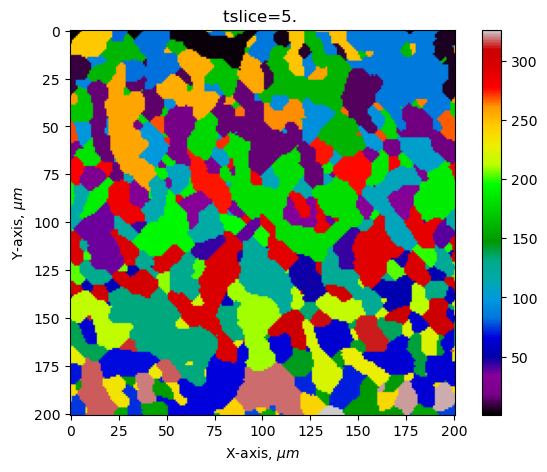

In [1052]:
kr.sgset[5].plotgs(figsize=(7, 5), dpi=100, cmap='nipy_spectral', title='')

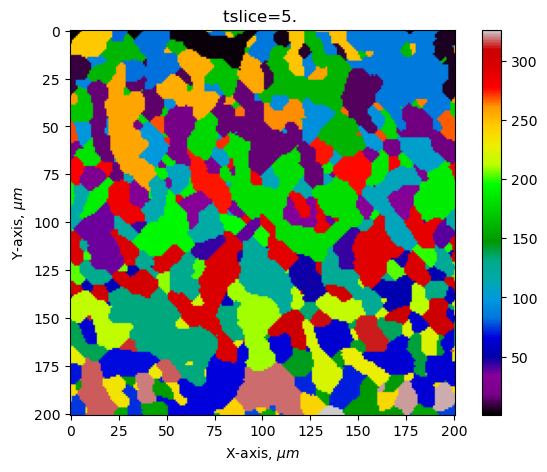

In [1053]:
kr.sgset[5].plotgs(figsize=(7, 5), dpi=100, cmap='nipy_spectral', title='')

In [1054]:
tslice = 9

In [1055]:
npixels = np.bincount(kr.sgset[tslice].lgi.ravel())[np.unique(kr.sgset[tslice].lgi.ravel())]

Text(0.5, 1.0, 'Sample set: KDE of grain pixel area temporal evolution')

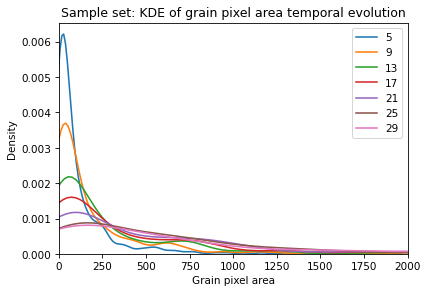

In [1056]:
plt.figure(figsize=(6, 4), dpi=75)
for tslice in np.array(list(kr.sgset.keys()))[5::4]:
    npixels = np.bincount(kr.sgset[tslice].lgi.ravel())[np.unique(kr.sgset[tslice].lgi.ravel())]
    sns.kdeplot(npixels, bw_adjust=0.5, legend=True, label=tslice, cumulative=False)
plt.legend()
plt.xlim(0, 2000)
plt.xlabel('Grain pixel area')
plt.ylabel('Density')
plt.title('Sample set: KDE of grain pixel area temporal evolution')

Text(0.5, 1.0, 'Target set: KDE of grain pixel area temporal evolution')

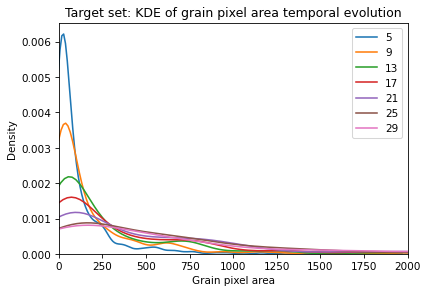

In [1057]:
plt.figure(figsize=(6, 4), dpi=75)
for tslice in np.array(list(kr.sgset.keys()))[5::4]:
    npixels = np.bincount(kr.tgset[tslice].lgi.ravel())[np.unique(kr.tgset[tslice].lgi.ravel())]
    sns.kdeplot(npixels, bw_adjust=0.5, legend=True, label=tslice)
plt.legend()
plt.xlim(0, 2000)
plt.xlabel('Grain pixel area')
plt.ylabel('Density')
plt.title('Target set: KDE of grain pixel area temporal evolution')

In [1058]:
print(40*'#')
print('\n\n    RUN = ', RUN, '\n\n')
print(40*'#')

########################################


    RUN =  3 


########################################


In [1059]:
if RUN == 1:
    ED_a = np.zeros(kr.rkf['ed'][1.0].shape+(10,))
    ED_b = np.zeros(kr.rkf['ed'][3.5].shape+(10,))
ED_a[:, :, RUN-1]= kr.rkf['ed'][1.0]
ED_b[:, :, RUN-1]= kr.rkf['ed'][3.5]

In [1060]:
RUN += 1

In [1061]:
print(f"Number of grains: {npixels.size}")

Number of grains: 50


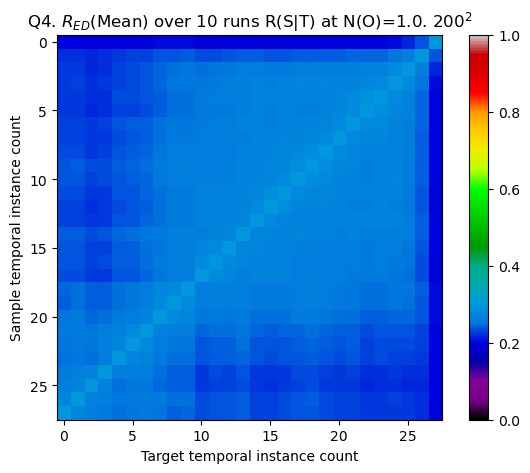

In [1062]:
plt.figure(figsize=(7, 5), dpi=100)
plt.imshow(np.flip(np.mean(ED_a, axis=2), axis=1), cmap='nipy_spectral', vmin=0, vmax=1)
plt.colorbar()
plt.xlabel('Target temporal instance count')
plt.ylabel('Sample temporal instance count')
plt.title('Q4. $R_{ED}$(Mean) over 10 runs R(S|T) at N(O)=1.0. $200^2$')
plt.show()

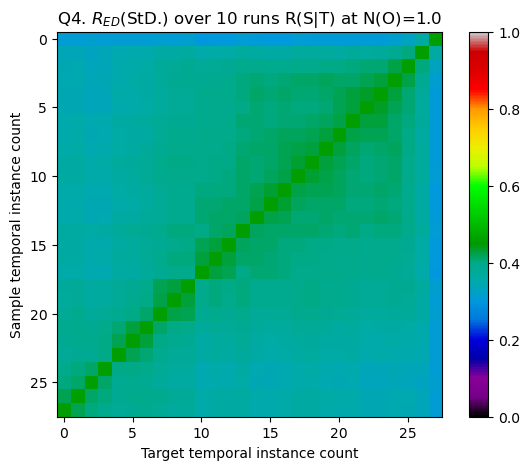

In [1063]:
plt.figure(figsize=(7, 5), dpi=100)
plt.imshow(np.flip(np.std(ED_a, axis=2), axis=1), cmap='nipy_spectral', vmin=0, vmax=1)
plt.colorbar()
plt.xlabel('Target temporal instance count')
plt.ylabel('Sample temporal instance count')
plt.title('Q4. $R_{ED}$(StD.) over 10 runs R(S|T) at N(O)=1.0')
plt.show()

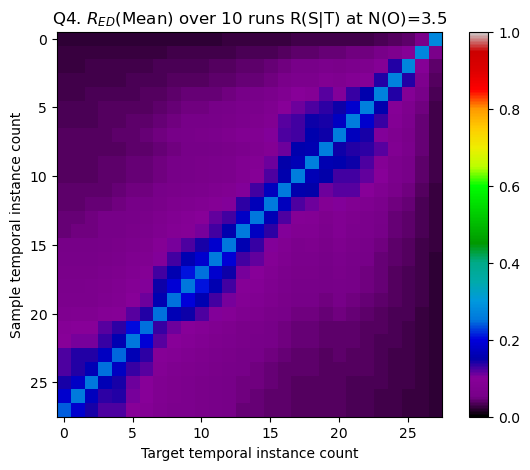

In [1064]:
plt.figure(figsize=(7, 5), dpi=100)
plt.imshow(np.flip(np.mean(ED_b, axis=2), axis=1), cmap='nipy_spectral', vmin=0, vmax=1)
plt.colorbar()
plt.xlabel('Target temporal instance count')
plt.ylabel('Sample temporal instance count')
plt.title('Q4. $R_{ED}$(Mean) over 10 runs R(S|T) at N(O)=3.5')
plt.show()

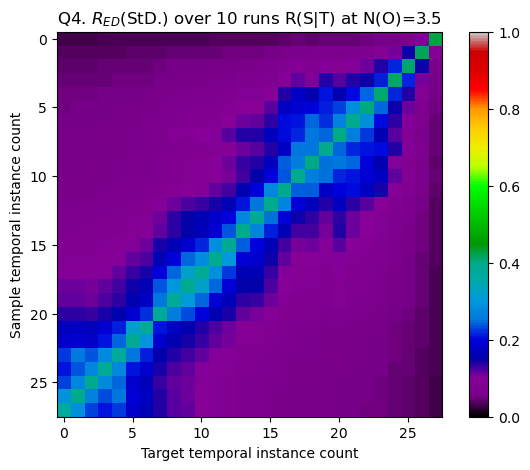

In [1065]:
plt.figure(figsize=(7, 5), dpi=100)
plt.imshow(np.flip(np.std(ED_b, axis=2), axis=1), cmap='nipy_spectral', vmin=0, vmax=1)
plt.colorbar()
plt.xlabel('Target temporal instance count')
plt.ylabel('Sample temporal instance count')
plt.title('Q4. $R_{ED}$(StD.) over 10 runs R(S|T) at N(O)=3.5')
plt.show()